In [12]:
from pathlib import Path

import torch
from PIL import Image
import matplotlib.pyplot as plt

from DocumentFigureClassifier.model import FigureClassifier
from DocumentFigureClassifier.taxonomy import TIER1_LABELS
from DocumentFigureClassifier.train.dataset import load_split

In [2]:
def collect_probs(clf: FigureClassifier, items, chunk: int = 64) -> tuple[torch.Tensor, torch.Tensor]:
    """Run the model over the split, returning (probs [M,N], targets [M])."""
    all_probs: list[torch.Tensor] = []
    targets: list[int] = []
    for i in range(0, len(items), chunk):
        batch = items[i : i + chunk]
        imgs = [Image.open(p).convert("RGB") for p, _ in batch]
        all_probs.append(clf.predict_proba(imgs))
        targets.extend(label_id for _, label_id in batch)
    probs = torch.cat(all_probs) if all_probs else torch.empty(0, N)
    return probs, torch.tensor(targets, dtype=torch.long)

In [3]:
split_index = Path("../data/splits/index.jsonl").resolve()
split = "test"

items = load_split(split_index, split)
print(f"loaded {len(items)} images from split '{split}'")

loaded 3340 images from split 'test'


In [4]:
model = Path("../models/tier1-stage2").resolve()
device = "cpu"

clf = FigureClassifier(model, device=device)

Loading weights: 100%|██████████| 360/360 [00:00<00:00, 3977.98it/s]


In [5]:
new_items = []

for item in items:
    path, label_id = item
    new_path = Path("../") / path  # adjust path to be relative to notebook
    new_items.append((new_path, label_id))

new_items[0]

(WindowsPath('../data/parsed_test/review/bar/adidas_ann_rep_2016__p069__097__bar__0.81.png'),
 0)

In [6]:
probs, targets = collect_probs(clf, new_items)

### Inspect Flow <-> Other confusion pairs

In [13]:
preds = probs.argmax(dim=1)                       # predicted label id per image
name2id = {name: i for i, name in enumerate(TIER1_LABELS)}

def find_confusions(actual: str, predicted: str) -> list[int]:
    """Row indices whose TRUE class is `actual` but the model predicted `predicted`."""
    a, p = name2id[actual], name2id[predicted]
    mask = (targets == a) & (preds == p)
    idx = mask.nonzero(as_tuple=True)[0].tolist()
    idx.sort(key=lambda i: probs[i, p].item(), reverse=True)   # most confident mistakes first
    return idx

def describe(idx: list[int]) -> None:
    for i in idx:
        path, true_id = new_items[i]
        p = probs[i]
        pred_id = int(p.argmax())
        print(f"{path.name}")
        print(f"  true={TIER1_LABELS[true_id]:12} pred={TIER1_LABELS[pred_id]:12} "
              f"p(pred)={p[pred_id]:.3f}  p(true)={p[true_id]:.3f}")

def show_grid(idx: list[int], ncols: int = 4, max_imgs: int = 16, size: float = 3.0) -> None:
    idx = idx[:max_imgs]
    if not idx:
        print("no matches")
        return
    nrows = (len(idx) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]
    for ax in axes:
        ax.axis("off")
    for ax, i in zip(axes, idx):
        path, true_id = new_items[i]
        p = probs[i]
        pred_id = int(p.argmax())
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(f"{TIER1_LABELS[true_id]}→{TIER1_LABELS[pred_id]}  "
                     f"p={p[pred_id]:.2f} (true {p[true_id]:.2f})", fontsize=9)
    fig.tight_layout()
    plt.show()

In [14]:
idx = find_confusions("flow", "other")
print(f"{len(idx)} 'flow' images classified as 'other'")
describe(idx)

55 'flow' images classified as 'other'
brit_am_tobacco_ann_rep_2024_en__p099__240__pie_donut__0.87.png
  true=flow         pred=other        p(pred)=0.950  p(true)=0.040
krones_ann_rep_2023__p067__140__flow__0.99.png
  true=flow         pred=other        p(pred)=0.940  p(true)=0.022
evonik_ann_rep_2024_de__p116__244__flow__0.92.png
  true=flow         pred=other        p(pred)=0.939  p(true)=0.043
brit_am_tobacco_ann_rep_2024_en__p124__311__pie_donut__0.82.png
  true=flow         pred=other        p(pred)=0.937  p(true)=0.050
glencore_ann_rep_2023_en__p015__088__flow__0.89.png
  true=flow         pred=other        p(pred)=0.917  p(true)=0.046
heid_mat_ann_rep_2023__p079__169__flow__0.78.png
  true=flow         pred=other        p(pred)=0.917  p(true)=0.065
brit_am_tobacco_ann_rep_2024_en__p108__268__pie_donut__0.82.png
  true=flow         pred=other        p(pred)=0.914  p(true)=0.061
diageo_ann_rep_2020_en__p008__049__flow__0.88.png
  true=flow         pred=other        p(pred)=0.913 

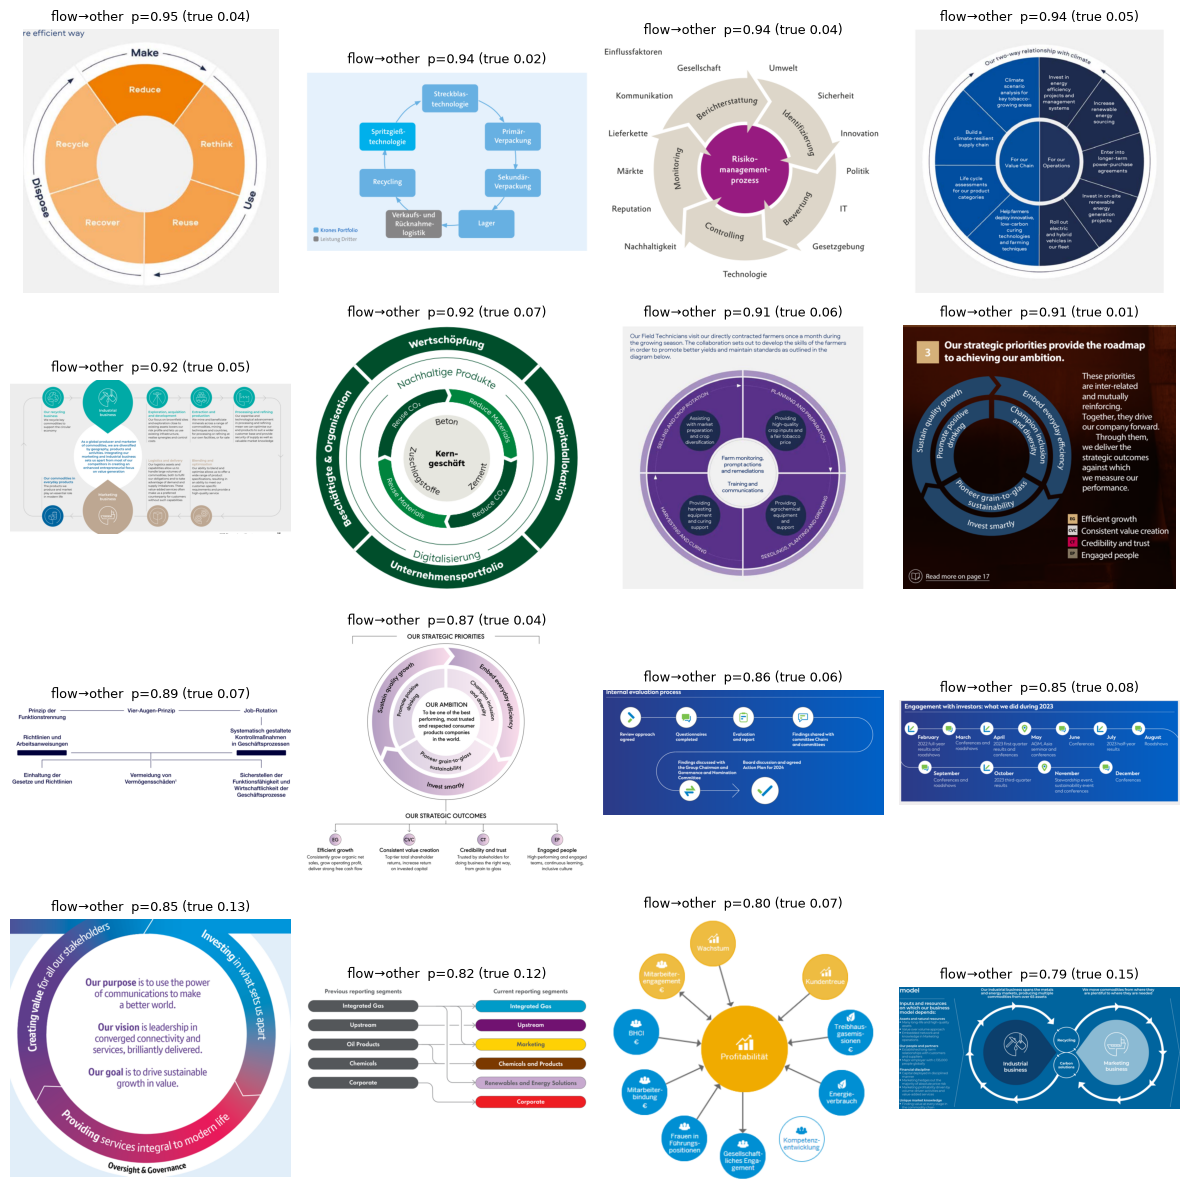

In [15]:
show_grid(idx)

In [16]:
idx = find_confusions("other", "flow")
print(f"{len(idx)} 'other' images classified as 'flow'")
describe(idx)

34 'other' images classified as 'flow'
adidas_ann_rep_2016__p061__090__flow__0.56.png
  true=other        pred=flow         p(pred)=0.952  p(true)=0.047
dbank_ann_rep_2025__p271__182__table__0.98.png
  true=other        pred=flow         p(pred)=0.799  p(true)=0.189
bp_ann_rep_2020_en__p024__065__flow__0.79.png
  true=other        pred=flow         p(pred)=0.773  p(true)=0.212
hsbc_ann_rep_2023_en__p067__153__flow__0.73.png
  true=other        pred=flow         p(pred)=0.748  p(true)=0.249
adidas_ann_rep_2016__p076__108__table__0.70.png
  true=other        pred=flow         p(pred)=0.704  p(true)=0.296
rio_tinto_ann_rep_2021_en__p018__008__flow__0.99.png
  true=other        pred=flow         p(pred)=0.687  p(true)=0.289
brit_am_tobacco_ann_rep_2024_en__p016__040__other__0.33.png
  true=other        pred=flow         p(pred)=0.677  p(true)=0.282
bt_group_ann_rep_2017_en__p057__126__other__0.73.png
  true=other        pred=flow         p(pred)=0.659  p(true)=0.130
dbank_ann_rep_2025__p72

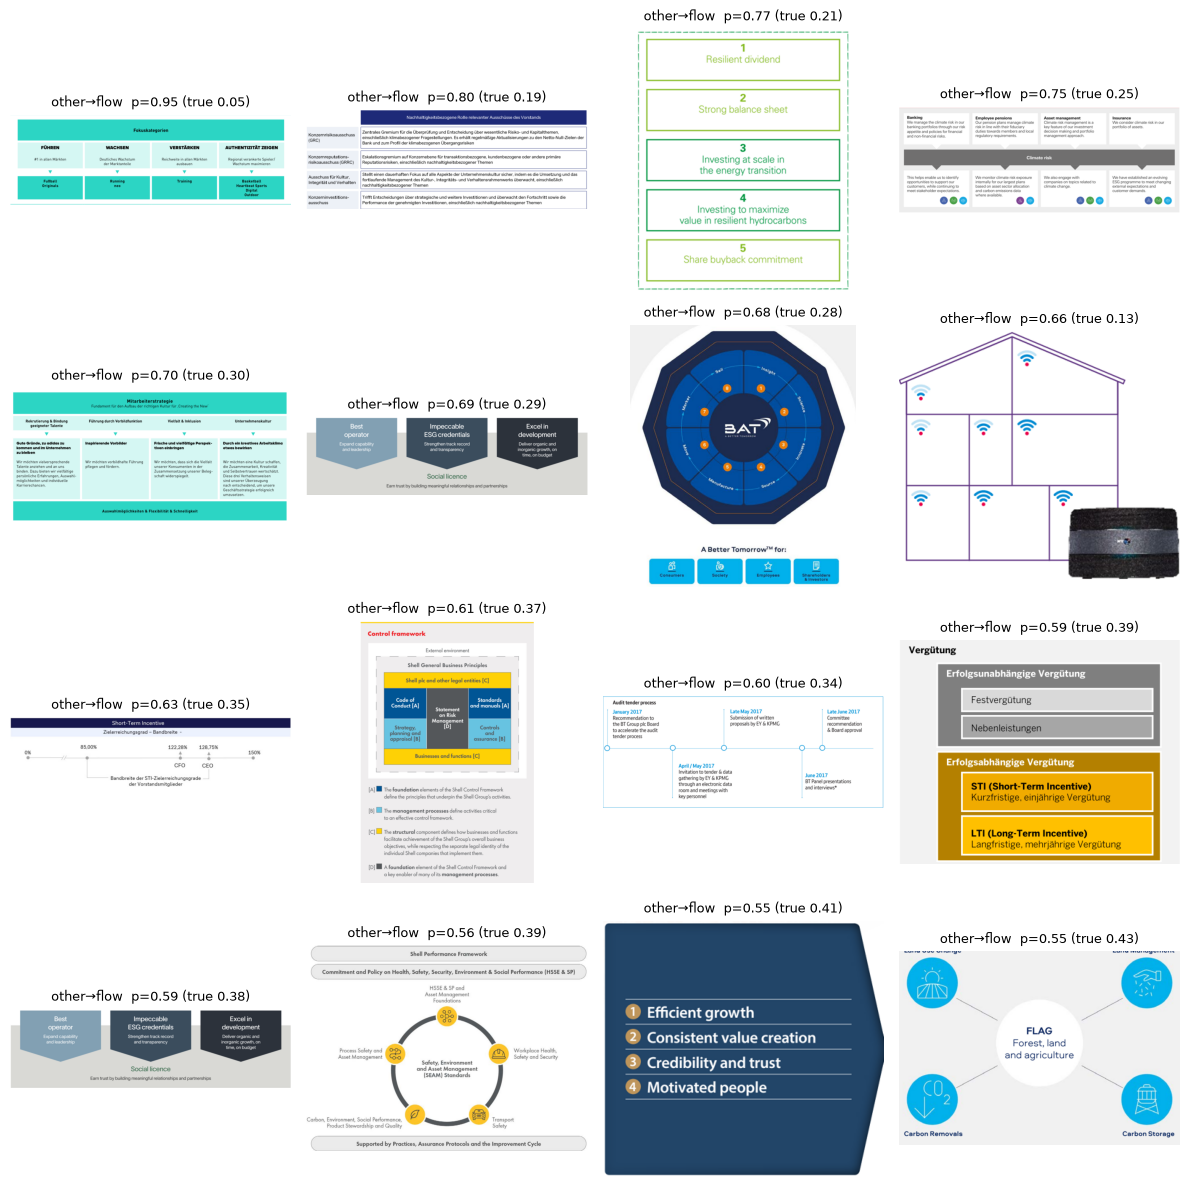

In [17]:
show_grid(idx)

In [8]:
type(probs), probs.shape, type(targets), targets.shape

(torch.Tensor, torch.Size([3340, 14]), torch.Tensor, torch.Size([3340]))

In [ ]:
probs[0]

tensor(0.7908)